# 1. Environment Setup

In [28]:
!pip install -q qdrant-client fastembed langchain-text-splitters datasets onnxruntime-gpu

In [29]:
import os
import re
import uuid
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from getpass import getpass
from google.colab import userdata

from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, SparseVectorParams, PointStruct
from qdrant_client.http import models

from datasets import load_dataset
from fastembed import TextEmbedding, SparseTextEmbedding
from sentence_transformers import SentenceTransformer

import onnxruntime as ort

from langchain_text_splitters import RecursiveCharacterTextSplitter


In [ ]:
pd.set_option('display.max_colwidth', None)

In [6]:
try:
    QDRANT_API_KEY = userdata.get('QDRANT_API_KEY')
except userdata.SecretNotFoundError:
    print("Enter your Qdrant API Key:")
    QDRANT_API_KEY = getpass()

In [4]:
QDRANT_URL = "https://d2dbde07-9613-45a2-a6ac-9184e92294b6.eu-west-1-0.aws.cloud.qdrant.io"
COLLECTION_NAME = "mental_health_hybrid"

In [5]:
client = QdrantClient(
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY
)

# 2. Database Setup

In [ ]:
# Check if collection exists; if so, delete it
if client.collection_exists(collection_name=COLLECTION_NAME):
    client.delete_collection(collection_name=COLLECTION_NAME)

# Initialize Qdrant to expect TWO vectors per document (Dense + Sparse)
client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config={
        # bge-base-en-v1.5 outputs 768 dimensions
        "dense-text": VectorParams(size=768, distance=Distance.COSINE),
    },
    sparse_vectors_config={
        "sparse-text": SparseVectorParams(),
    }
)

print("Qdrant Cloud Collection Created")

Qdrant Cloud Collection Created


# 3. Model Initialization

In [40]:
dense_model = TextEmbedding(model_name="BAAI/bge-base-en-v1.5")

sparse_model = SparseTextEmbedding(model_name="prithvida/Splade_PP_en_v1")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_2531/2620698681.py:3: DeprecationWarning: The right spelling is prithivida/Splade_PP_en_v1. Support of this name will be removed soon, please fix the model_name
  sparse_model = SparseTextEmbedding(model_name="prithvida/Splade_PP_en_v1")


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

# 4. Test Chuncking and Embedding

## 4.1. Data Mocking & Chunking

In [ ]:
raw_counseling_text = """
Panic attacks can feel incredibly overwhelming, often mimicking the physical symptoms of a heart attack.
When experiencing a panic attack, the 4-7-8 breathing technique is highly effective. Inhale for 4 seconds, hold for 7, and exhale for 8.
Another strategy for anxiety is cognitive reframing. This involves identifying irrational fears and challenging them with evidence.
If you are struggling with severe burnout, the most important first step is aggressive rest and setting hard boundaries at work.
"""

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=150,
    chunk_overlap=30,
    separators=["\n\n", "\n", ".", " "]
)
chunks = text_splitter.split_text(raw_counseling_text)
print(f"Generated {len(chunks)} chunks")

Generated 4 chunks


## 4.2. Embedding & Uploading to Cloud

In [ ]:
dense_embeddings = list(dense_model.embed(chunks))
sparse_embeddings = list(sparse_model.embed(chunks))

# Package into Qdrant Payloads
points = []
for i, chunk in enumerate(chunks):
    point_id = str(uuid.uuid4())

    points.append(PointStruct(
        id=point_id,
        payload={"text": chunk},
        vector={
            "dense-text": dense_embeddings[i].tolist(),
            "sparse-text": sparse_embeddings[i].as_object()
        }
    ))

# Push to the cloud database
client.upsert(
    collection_name=COLLECTION_NAME,
    points=points
)

print("Data is live in Qdrant Cloud cluster")

Data is live in Qdrant Cloud cluster


# 5. Data Ingestion

In [ ]:
dataset = load_dataset("Amod/mental_health_counseling_conversations")

In [ ]:
df = dataset['train'].to_pandas()
print(f"Total conversations: {len(df):,}")

Total conversations: 3,512


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3512 entries, 0 to 3511
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Context   3512 non-null   object
 1   Response  3512 non-null   object
dtypes: object(2)
memory usage: 55.0+ KB


In [ ]:
df.head()

,Context,Response
0,"I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n How can I change my feeling of being worthless to everyone?","If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and be knocked down again.There are many inspirational messages you can find in social media. Maybe read some of the ones which state that no person is worthless, and that everyone has a good purpose to their life.Also, since our culture is so saturated with the belief that if someone doesn't feel good about themselves that this is somehow terrible.Bad feelings are part of living. They are the motivation to remove ourselves from situations and relationships which do us more harm than good.Bad feelings do feel terrible. Your feeling of worthlessness may be good in the sense of motivating you to find out that you are much better than your feelings today."
1,"I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n How can I change my feeling of being worthless to everyone?","Hello, and thank you for your question and seeking advice on this. Feelings of worthlessness is unfortunately common. In fact, most people, if not all, have felt this to some degree at some point in their life. You are not alone. Changing our feelings is like changing our thoughts - it's hard to do. Our minds are so amazing that the minute you change your thought another one can be right there to take it's place. Without your permission, another thought can just pop in there. The new thought may feel worse than the last one! My guess is that you have tried several things to improve this on your own even before reaching out on here. People often try thinking positive thoughts, debating with their thoughts, or simply telling themselves that they need to ""snap out of it"" - which is also a thought that carries some self-criticism. Some people try a different approach, and there are counselors out there that can help you with this. The idea is that instead of trying to change the thoughts, you change how you respond to them. You learn skills that allow you to manage difficult thoughts and feelings differently so they don't have the same impact on you that they do right now. For some people, they actually DO begin to experience less hurtful thoughts once they learn how to manage the ones they have differently. Acceptance and Commitment Therapy may be a good choice for you. There is information online and even self-help books that you can use to teach you the skills that I mentioned. Because they are skills, they require practice, but many people have found great relief and an enriched life by learning them. As for suicidal thoughts, I am very glad to read that this has not happened to you. Still, you should watch out for this because it can be a sign of a worsening depression. If you begin to think about this, it is important to reach out to a support system right away. The National Suicide Prevention Lifeline is 1-800-273-8255. The text line is #741741. I hope some other colleagues will provide you more suggestions. Be well...Robin Landwehr, DBH, LPCC"
2,"I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n How

In [ ]:
df.sample(10)

,Context,Response
2138,They're calling me names like hypocrite and a baby even when they act in the same manner as I do. I'm tired of being called names. What should I do?,"It sounds like your confused as to why your friends would be calling you a hypocrite when they act in the same manner, correct? Communication is key to any relationship. I would recommend speaking with your friends face-to-face to address why they feel your behavior is concerning. In-person contact is the best method of sorting out differences considering texts, emails or any written response can be misconstrued. Be upfront with them and let them know that being accused of hypocrisy is hurtful and you feel it is unfounded. If after speaking with them you feel that they have valid reasons for the way they are feeling, maybe you can consider modifying your behavior accordingly. Especially if this friendship is valuable to you. However, make sure they are aware that there is a respectful way to address these issues and name calling is not one of them. On the other hand, if you feel that their reasons are indeed unfounded, it may be best to distance yourself from the relationship. Not all friendships are healthy ones. And it is important that you surround yourself with people who are an asset to your self esteem as opposed to those that hinder it.I hope you are able to get this matter sorted. Best of luck!"
256,"I stopped for a while, but I’ve started doing it again. It’s like an addiction. The more I try to stop, the more I want to do it. I’ve tried doing some of the stuff they say to do like draw, but it doesn’t work.","I've heard people say that they cut themselves as a way to feel relief from different emotions. You're also right that when you try to focus on just not cutting, it becomes more difficult because it's what you are focused on. While that is still something to work on, it may also be helpful to find something else you can do instead. You said drawing doesn't work for you. Sometimes more physical activities, such as doing a few jumping jacks, can be helpful. If you don't exercise, it might be something to talk with your doctor about first.The more you can learn about what makes you want to cut, the easier it will be to find out what you could do to change that. Try talking to somebody about what you are feeling in addition to the urge to cut."
2584,"We just cannot seem to get along. I cannot have a conversation with her without it turning into World War 3. She treats me like I have no right to an opinion and never really lets me speak. My real mother cares and tries to help me, but she can't do much, because my adoptive mother won't listen to her either.","Going to see a experience counselor would be my advice. You will have a neutral person that can listen to both sides and help you all find a common ground of understanding. If she doesn't agree to counseling, really the only person you can change is you. I would suggest that you approach her with love and let her know what you appreciate about her, let her know the great things she have done that could not be replaced or forgotten however you want your relationship to get better than it has been lately. Hopefully this will open the door of communication where you can explain your thoughts and feeling but in a loving way."
2442,"My husband’s ex-wife married a man who was charged with seven felony counts of pandering involving a minor. He, by his own admission, is addicted to child pornography. My step-daughters are now all teenagers. They do not know. My husband’s ex-wife has kept this information from my step-daughters. The step-father has had issues regarding his pornography addiction recently. The ex-wife minimizes it by saying that he has ""repented."" It is a constant strain on my husband, knowing that his girls are living with a man who is addicted to child pornography. My own therapist believes the girls should be told. The ex-wife says her therapist says the opposite.",If the daughters a

# 6. EDA

## 6.1. Check Duplicated `'context'`

In [ ]:
duplicate_mask = df.duplicated(subset=['Context'], keep=False)
duplicates_df = df[duplicate_mask].sort_values(by='Context')

print(f"Total rows in dataset: {len(df)}")
print(f"Total rows involved in duplicates: {len(duplicates_df)} ({(len(duplicates_df) / len(df) * 100):.2f} %)")

Total rows in dataset: 3512
Total rows involved in duplicates: 3276 (93.28 %)


In [ ]:
duplicates_df.head()

,Context,Response
3352,"A few years ago I was making love to my wife when for no known reason I lost my erection, \r\n\r\nNow I'm In my early 30s and my problem has become more and more frequent. This is causing major problems for my ego and it's diminishing my self esteem. This has resulted in ongoing depression and tearing apart my marriage. \r\n\r\nI am devastated and cannot find a cause for these issues. I am very attracted to my wife and want to express it in the bedroom like I used to. \r\n\r\nWhat could be causing this, and what can I do about it?","First step always is to do a medical rule out so that you're sure the problem is psychological and emotion based, not a medical condition which requires care and attention.If you are medically clear in the reasons for losing your erection, then reflect on what may be creating a loss in confidence in either who you are and what you're doing with your life, or whether your wife has these sort of problems within herself.Often a problem transfers ownership of who shows it.If you are a sensitive person its possible your erection problem reflects your wife's insecurities and self-doubt. If she is someone who is reluctant to talk about feeling unsure then in a certain way by you showing a problem, she can avoid looking at herself.There may not be a direct cause such as usually exists in a medical problem.Medicine looks for symptoms to treat.Our emotional lives are much more indirect.If you feel stress at work or are unhappy in the place you live, for example, then your frustration may show up in your sex life.Basically, do a broad inward search of your life and what it holds and maybe ask your wife to do the same.You may clear the air within yourselves and between each other so the problem goes away."
3356,"A few years ago I was making love to my wife when for no known reason I lost my erection, \r\n\r\nNow I'm In my early 30s and my problem has become more and more frequent. This is causing major problems for my ego and it's diminishing my self esteem. This has resulted in ongoing depression and tearing apart my marriage. \r\n\r\nI am devastated and cannot find a cause for these issues. I am very attracted to my wife and want to express it in the bedroom like I used to. \r\n\r\nWhat could be causing this, and what can I do about it?","When I'm working with men with this type of situation, I always suggest a medical examination to rule out any type of organic reason for a difficulty in maintaining interaction. In cases where there is no medical reason for the loss of erection, I find that many men have a similar situation in experiencing negative intrusive thinking during lovemaking. My counseling approach for this situation is to incorporate the use of mindful sex."
3360,"A few years ago I was making love to my wife when for no known reason I lost my erection, \r\n\r\nNow I'm In my early 30s and my problem has become more and more frequent. This is causing major problems for my ego and it's diminishing my self esteem. This has resulted in ongoing depression and tearing apart my marriage. \r\n\r\nI am devastated and cannot find a cause for these issues. I am very attracted to my wife and want to express it in the bedroom like I used to. \r\n\r\nWhat could be causing this, and what can I do about it?","For starters, know that this is a normal experience for many men at some point in their lives. While this can certainly cause some embarrassment, a diminished sexual esteem or relationship problems, it is important to know you are not alone. I am going to move forward assuming that you have already checked with a medical professional to rule out any medical problems that may be related to this. Assuming that is the case, for most this happens for two primary reasons. It is either a short term biological shortage of blood flow to the penis. This can be caused my diet, lack of exercise, even stress. Another primary reason for loss of erections are anxiety. Have their been recent relatio

* Most of the questions have multiple answers.
* Multiple answers can be merged in a mega-document under one question.

## 6.2. Create Mega-Responses

### 6.2.1. Group by `'context'`

In [ ]:
def create_mega_response(responses):
    mega_text = ""

    for i, resp in enumerate(responses):
        mega_text += f"\n\nCounselor {i+1} Advice:\n{resp}"

    return mega_text.strip()

In [ ]:
# Group the dataset by the patient's problem (Context)
mega_df = df.groupby('Context')['Response'].apply(list).reset_index()
mega_df['Mega_Response'] = mega_df['Response'].apply(create_mega_response)

print(f"Total Unique Scenarios (Mega-Documents): {len(mega_df)}")

Total Unique Scenarios (Mega-Documents): 995


In [ ]:
mega_df.head()

Context  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           such as not enough sleep   
1  A few nights ago I talked to this girl I know about my self esteem issues for the first time. We talked for hours and she told me time and again that I was a great guy. She told me I was attractive, and have a great personality, etc. I really started to feel better about myself by the time I woke up the next morning.\nNow, though, I can't stop thinking about her, but I leave to go back to college in a few days and I go to school 4 hours away from her. So now I feel constantly depressed because even if I told her how I felt it wouldn't matter. I feel helpless and I don't know what to do.   
2   A few nights ago I talked to this girl I know about my self esteem issues for the first time. We talked for hours and she told me time and again that I was a great guy. She told me I was attractive, and have a great personality, etc. I really started to feel better about myself by the time I woke up the next morning. Now, though, I can't stop thinking about her, but I leave to go back to college in a few days and I go to school 4 hours away from her. So now I feel constantly depressed because even if I told her how I felt it wouldn't matter. I feel helpless and I don't know what to do.   
3                                                          A few years ago I was making love to my wife when for no known reason I lost my erection, \r\n\r\nNow I'm In my early 30s and my problem has become more and more frequent.  This is causing major problems for my ego and it's diminishing my self esteem. This has resulted in ongoing depression and tearing apart my marriage. \r\n\r\nI am devastated and cannot find a cause for these issues. I am very attracted to my wife and want to express it in the bedroom like I used to. \r\n\r\nWhat could be causing this, and what can I do about it?   
4                                                                          A few years ago I was making love to my wife when for no known reason I lost my erection,    Now I'm In my early 30s and my problem has become more and more frequent. This is causing major problems for my ego and it's diminishing my self esteem. This has resulted in ongoing depression and tearing apart my marriage.    I am devastated and cannot find a cause for these issues. I am very attracted to my wife and want to express it in the bedroom like I used to.    What could be causing this, and what can I do about it?   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

* Some contexts are similar but have extra `\n`.

### 6.2.2. Normalize `'context'`

In [ ]:
# Strip line breaks and extra spaces so Pandas can match duplicates
def clean_text(text):
    # Replace newlines and carriage returns with a space
    text = re.sub(r'[\n\r]+', ' ', text)
    # Replace multiple spaces with a single space
    text = re.sub(r'\s{2,}', ' ', text)
    return text.strip()

In [ ]:
df['Context'] = df['Context'].apply(clean_text)

* Removing newlines, carriage returns, and muliple spaces will not destroy chuncking because we have added `\n\n` between each counselor's response in the mega response.

In [ ]:
# Group by the cleaned Context
mega_df = df.groupby('Context')['Response'].apply(list).reset_index()
mega_df['Mega_Response'] = mega_df['Response'].apply(create_mega_response)

print(f"Total Unique Scenarios (Mega-Documents): {len(mega_df)}")

Total Unique Scenarios (Mega-Documents): 831


In [ ]:
mega_df.head()

Context  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     A few nights ago I talked to this girl I know about my self esteem issues for the first time. We talked for hours and she told me time and again that I was a great guy. She told me I was attractive, and have a great personality, etc. I really started to feel better about myself by the time I woke up the next morning. Now, though, I can't stop thinking about her, but I leave to go back to college in a few days and I go to school 4 hours away from her. So now I feel constantly depressed because even if I told her how I felt it wouldn't matter. I feel helpless and I don't know what to do.   
1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     A few years ago I was making love to my wife when for no known reason I lost my erection, Now I'm In my early 30s and my problem has become more and more frequent. This is causing major problems for my ego and it's diminishing my self esteem. This has resulted in ongoing depression and tearing apart my marriage. I am devastated and cannot find a cause for these issues. I am very attracted to my wife and want to express it in the bedroom like I used to. What could be causing this, and what can I do about it?   
2  A friend of mine taking psychology advised I go to my doctor to check if I have major depressive disorder. I'm afraid of the consequences of doing so. If I do become diagnosed with major depressive disorder, won’t that go on my records? I will never be able to become a counselor along with a list of other things I may be prohibited from. I’m also afraid of taking any anti-depressants. This year, my doctor gave me some for a "dislocated hip." I had a severe reaction and passed out moments after taking them. Everyone I know who has taken anti-depressants says it’s a bad idea all around and you’re better getting treatment without them. I’m concerned they might take me to a clinic and force me to take medication because I am unable to make decisions on my own. I’m not really suicidal, but I am not really taking care of myself either. Someone also told me they still use electroshock therapy. I’m not keen on that. I’m wondering if I am better off just getting self-help and working things out on my own. It’s just that I've been an emotional mess since I was in elementary school. I’ve graduated now and tried to stay positive and be happy, but I cannot deny I still am not good.   
3                                                                                                                                                                                                                                                                                                                                                                                                                      

* In row 0 and 2, advice 1 and 2 are identical. There are duplicated rows.

### 6.2.3. Check Duplicated Rows

In [ ]:
row_dup_mask = df.duplicated(subset=['Context', 'Response'], keep=False)
row_dups_df = df[row_dup_mask].sort_values(by='Context')

total_row_dups = df.duplicated(subset=['Context', 'Response']).sum()

print(f"Number of redundant rows to be dropped: {total_row_dups}")

Number of redundant rows to be dropped: 1028


In [ ]:
row_dups_df.head(10)

,Context,Response
806,"A few nights ago I talked to this girl I know about my self esteem issues for the first time. We talked for hours and she told me time and again that I was a great guy. She told me I was attractive, and have a great personality, etc. I really started to feel better about myself by the time I woke up the next morning. Now, though, I can't stop thinking about her, but I leave to go back to college in a few days and I go to school 4 hours away from her. So now I feel constantly depressed because even if I told her how I felt it wouldn't matter. I feel helpless and I don't know what to do.","Hey! It takes a lot of courage to share your feelings with someone! And it sounds like you have been lucky to meet someone who makes you feel safe enough to explore some of your more painful feelings. A big part of the process, however, of strengthening your self-concept is learning how to tell yourself those positive messages that you heard from your friend! Leaving for college may also be contributing to your feelings of unsteadiness. Try this - Make a list of all of the positive things that you know are true about yourself. Ask your friends and family to contribute to the list. Then carry it with you in your wallet - and when you need a self-esteem boost, take a look at it! You are in a season of life that presents lots of challenges and opportunities. Reach out to your long-distance friend when you need support - and take a walk over to the campus counseling center and check out what they might have to offer. Be Wise!"
2186,"A few nights ago I talked to this girl I know about my self esteem issues for the first time. We talked for hours and she told me time and again that I was a great guy. She told me I was attractive, and have a great personality, etc. I really started to feel better about myself by the time I woke up the next morning. Now, though, I can't stop thinking about her, but I leave to go back to college in a few days and I go to school 4 hours away from her. So now I feel constantly depressed because even if I told her how I felt it wouldn't matter. I feel helpless and I don't know what to do.","Hey! It takes a lot of courage to share your feelings with someone! And it sounds like you have been lucky to meet someone who makes you feel safe enough to explore some of your more painful feelings. A big part of the process, however, of strengthening your self-concept is learning how to tell yourself those positive messages that you heard from your friend! Leaving for college may also be contributing to your feelings of unsteadiness. Try this - Make a list of all of the positive things that you know are true about yourself. Ask your friends and family to contribute to the list. Then carry it with you in your wallet - and when you need a self-esteem boost, take a look at it! You are in a season of life that presents lots of challenges and opportunities. Reach out to your long-distance friend when you need support - and take a walk over to the campus counseling center and check out what they might have to offer. Be Wise!"
89,"A few years ago I was making love to my wife when for no known reason I lost my erection, Now I'm In my early 30s and my problem has become more and more frequent. This is causing major problems for my ego and it's diminishing my self esteem. This has resulted in ongoing depression and tearing apart my marriage. I am devastated and cannot find a cause for these issues. I am very attracted to my wife and want to express it in the bedroom like I used to. What could be causing this, and what can I do about it?","First step always is to do a medical rule out so that you're sure the problem is psychological and emotion based, not a medical condition which requires care and attention.If you are medically clear in the reasons for losing your erection, then reflect on what may be creating a loss in confidence in either who you are and what you're doing with your life, or whether your wife has these

In [ ]:
df = df.drop_duplicates(subset=['Context', 'Response'])

print(f"Row count after removing duplicated rows: {len(df)}")

Row count after removing duplicated rows: 2484


In [ ]:
# Re-group the Mega-Documents after removing duplicated rows
mega_df = df.groupby('Context')['Response'].apply(list).reset_index()
mega_df['Mega_Response'] = mega_df['Response'].apply(create_mega_response)

print(f"Total Unique Scenarios (Mega-Documents): {len(mega_df)}")

Total Unique Scenarios (Mega-Documents): 831


## 6.2.4. Document Length Distribution

In [ ]:
df['context_len'] = df['Context'].str.len()
df['response_len'] = df['Response'].str.len()
mega_df['mega_response_len'] = mega_df['Mega_Response'].str.len()

print("Statistical Metrics (Character Counts)\n")

print("===== Patient Contexts =====")
display(df['context_len'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

print("\n===== Individual Responses =====")
display(df['response_len'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

print("\n===== Mega-Responses =====")
display(mega_df['mega_response_len'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

Statistical Metrics (Character Counts)

===== Patient Contexts =====


,context_len
count,2484.000000
mean,278.220209
std,242.124165
min,24.000000
1%,37.000000
5%,56.000000
25%,144.500000
50%,232.000000
75%,338.750000
95%,657.000000



===== Individual Responses =====


,response_len
count,2484.000000
mean,1025.798309
std,1120.285109
min,0.000000
1%,120.830000
5%,257.000000
25%,522.000000
50%,821.500000
75%,1266.000000
95%,2380.400000



===== Mega-Responses =====


,mega_response_len
count,831.000000
mean,3129.929001
std,4351.050823
min,21.000000
1%,258.800000
5%,453.500000
25%,875.500000
50%,1656.000000
75%,3527.500000
95%,10603.000000


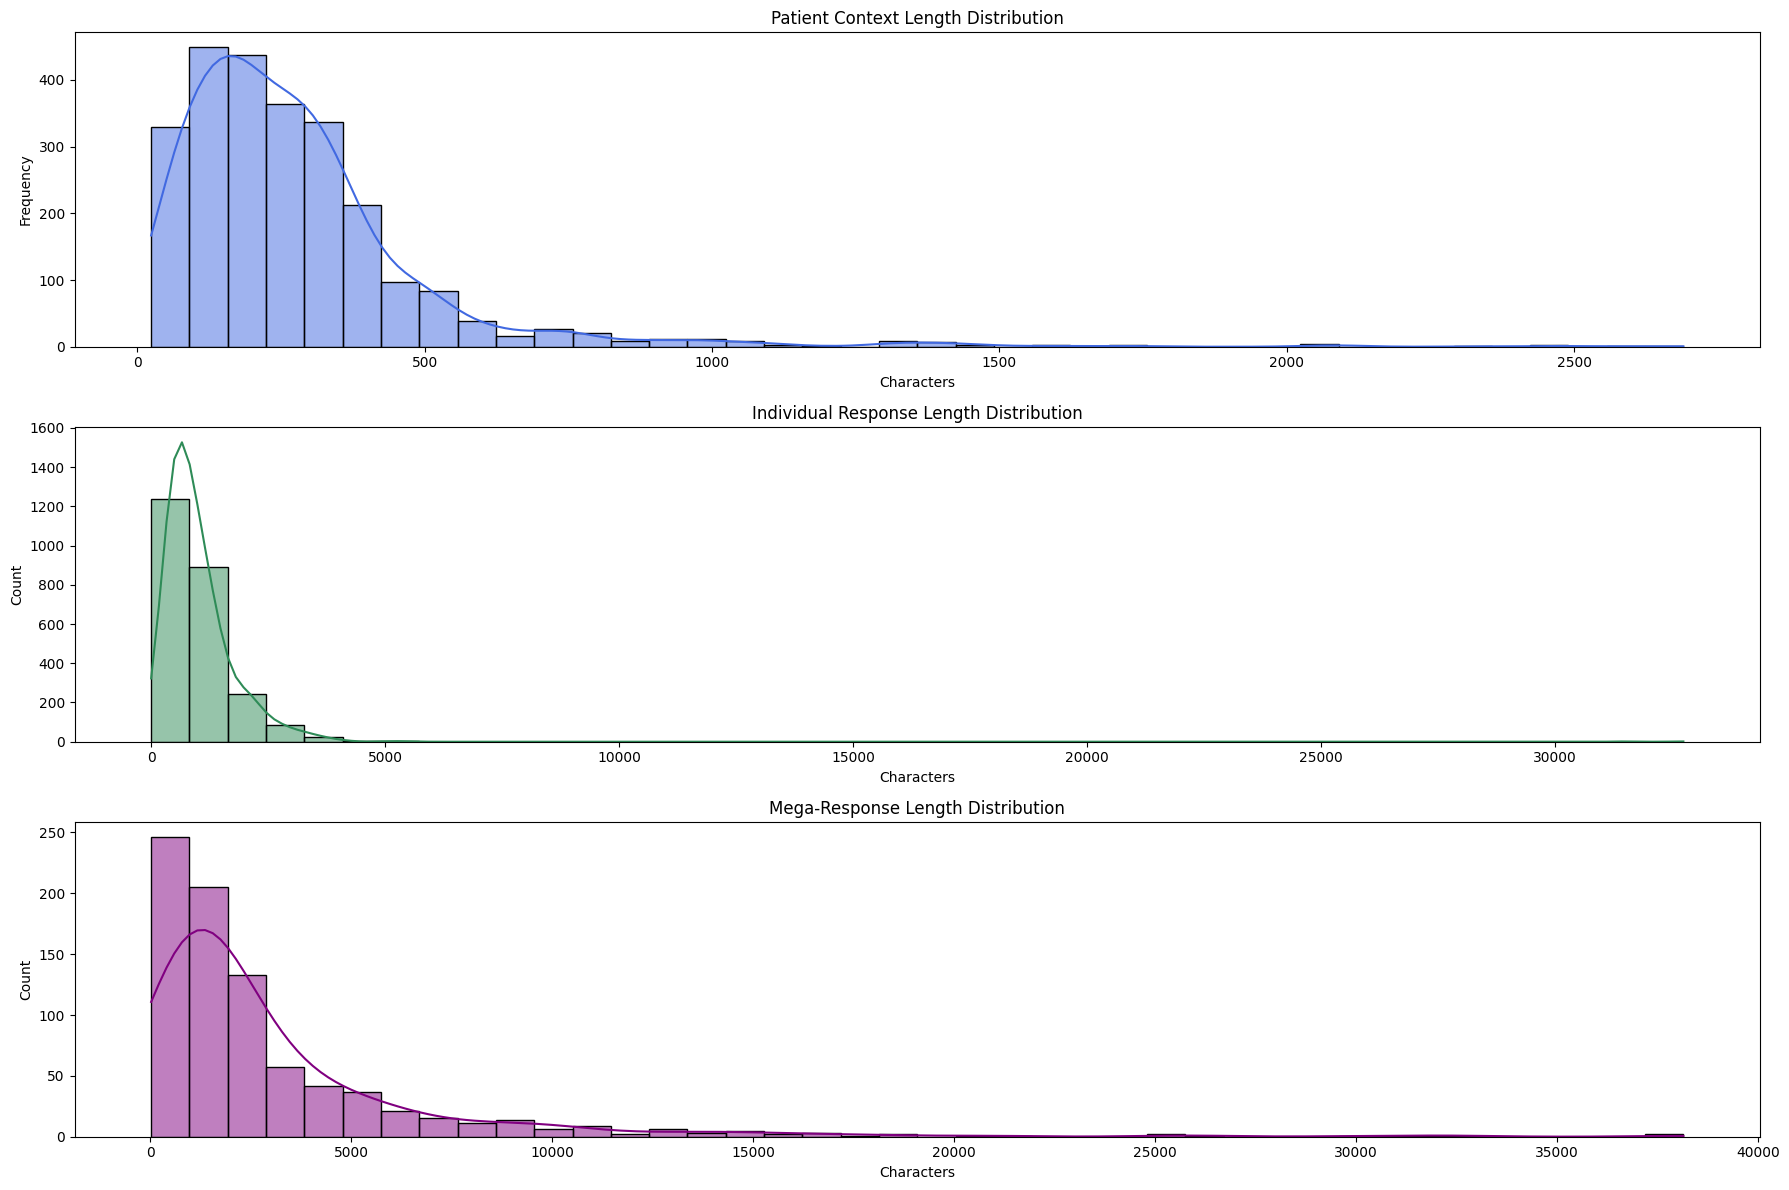

In [ ]:
plt.figure(figsize=(18, 12))

# Patient Context
plt.subplot(3, 1, 1)
sns.histplot(df['context_len'], bins=40, kde=True, color='royalblue')
plt.title('Patient Context Length Distribution')
plt.xlabel('Characters')
plt.ylabel('Frequency')

# Individual Response
plt.subplot(3, 1, 2)
sns.histplot(df['response_len'], bins=40, kde=True, color='seagreen')
plt.title('Individual Response Length Distribution')
plt.xlabel('Characters')

# Mega-Response
plt.subplot(3, 1, 3)
sns.histplot(mega_df['mega_response_len'], bins=40, kde=True, color='purple')
plt.title('Mega-Response Length Distribution')
plt.xlabel('Characters')

plt.tight_layout()
plt.show()

In [ ]:
# Patient Context
fig1 = px.histogram(
    df,
    x="context_len",
    nbins=50,
    marginal="box",
    title="Patient Context Length Distribution",
    labels={'context_len': 'Character Count'},
    color_discrete_sequence=['royalblue']
)
fig1.show()

In [ ]:
# Individual Response
fig2 = px.histogram(
    df,
    x="response_len",
    nbins=50,
    marginal="box",
    title="Individual Response Length Distribution",
    labels={'response_len': 'Character Count'},
    color_discrete_sequence=['seagreen']
)
fig2.show()

In [ ]:
# Mega-Response
fig3 = px.histogram(
    mega_df,
    x="mega_response_len",
    nbins=50,
    marginal="box",
    title="Mega-Response Length Distribution",
    labels={'mega_response_len': 'Character Count'},
    color_discrete_sequence=['purple']
)
fig3.show()

# 7. ETL Script

In [ ]:
# ETL Pipeline Configurations
ETL_CONFIG = {
    "dataset_name": "Amod/mental_health_counseling_conversations",
    "junk_threshold": 50,
    "chunk_size": 800,
    "chunk_overlap": 100
}

## 7.1. Extract Module

In [ ]:
def extract_data(dataset_name: str) -> pd.DataFrame:
    """Extracts dataset from Hugging Face."""
    print(f"Phase 1: Extracting data from {dataset_name}...")
    dataset = load_dataset(dataset_name)
    df = dataset['train'].to_pandas()
    print(f"   -> Extracted {len(df)} raw rows")
    return df

## 7.2. Transform Module

In [ ]:
def clean_text(text: str) -> str:
    """Removes hidden newlines and normalizes spacing."""

    # Replace newlines and carriage returns with a space
    text = re.sub(r'[\n\r]+', ' ', text)

    # Replace multiple spaces with a single space
    text = re.sub(r'\s{2,}', ' ', text)

    return text.strip()

In [ ]:
def clean_dataframe(df: pd.DataFrame, junk_threshold: int) -> pd.DataFrame:
    """Cleans the dataframe by normalizing contexts, dropping duplicated rows, and dropping junk (short) data."""
    print("\nPhase 2: Cleaning Data...")

    # Normalize text
    df['Context'] = df['Context'].apply(clean_text)

    # Drop duplicated rows
    initial_count = len(df)
    df = df.drop_duplicates(subset=['Context', 'Response'])
    print(f"   -> Dropped {initial_count - len(df)} exact duplicate rows")

    # Drop junk data
    df = df.dropna(subset=['Context', 'Response'])
    df = df[(df['Context'].str.len() > junk_threshold) & (df['Response'].str.len() > junk_threshold)]
    print(f"   -> Cleaned row count: {len(df)}")

    return df

In [ ]:
def build_mega_documents(df: pd.DataFrame) -> pd.DataFrame:
    """Groups responses with identical context."""
    print("\nPhase 3: Stitching Mega-Documents...")

    def create_mega_response(responses):
        mega_text = ""
        for i, resp in enumerate(responses):
            mega_text += f"\n\nCounselor {i+1} Advice:\n{resp}"
        return mega_text.strip()

    mega_df = df.groupby('Context')['Response'].apply(list).reset_index(name='Responses_List')
    mega_df['Mega_Response'] = mega_df['Responses_List'].apply(create_mega_response)

    print(f"   -> Total Unique Scenarios: {len(mega_df)}")
    return mega_df

In [ ]:
def chunk_and_decouple_data(mega_df: pd.DataFrame, chunk_size: int, chunk_overlap: int) -> dict:
    """Chunks data and separates it into Vector Store payloads and Document Store payloads."""
    print("\nPhase 4: Chunking and Decoupling (Multi-Vector Indexing)...")

    # Chuncker
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ".", "!", "?", " "]
    )

    vector_payloads = []
    docstore_payloads = {}

    for index, row in mega_df.iterrows():
        parent_id = f"scenario_{index}"
        patient_context = row['Context']
        mega_advice = row['Mega_Response']

        # ===== Document Store (for the LLM) =====
        docstore_payloads[parent_id] = {
            "patient_context": patient_context,
            "counselor_advice": mega_advice
        }

        # ===== Vectore Store (for Qdrant) =====

        # Embed the Context
        context_chunks = text_splitter.split_text(patient_context)
        for chunk in context_chunks:
            vector_payloads.append({
                "parent_id": parent_id,
                "doc_type": "patient_problem",
                "text_to_embed": chunk
            })

        # Embed the Advice
        advice_chunks = text_splitter.split_text(mega_advice)
        for chunk in advice_chunks:
            vector_payloads.append({
                "parent_id": parent_id,
                "doc_type": "counselor_advice",
                "text_to_embed": chunk
            })

    print(f"   -> Generated {len(docstore_payloads)} parent documents for the LLM")
    print(f"   -> Generated {len(vector_payloads)} decoupled vector chunks for Qdrant")

    return {
        "vector_payloads": vector_payloads,
        "docstore_payloads": docstore_payloads
    }

In [ ]:
def chunk_and_decouple_data(mega_df: pd.DataFrame, chunk_size: int, chunk_overlap: int) -> dict:
    """Chunks data and separates it into Vector Store payloads and Document Store payloads."""
    print("\nPhase 4: Chunking and Decoupling (Multi-Vector Indexing)...")

    # Chuncker
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ".", "!", "?", " "]
    )

    vector_payloads = []
    docstore_payloads = {}

    for index, row in mega_df.iterrows():
        parent_id = f"scenario_{index}"

        # ===== Document Store (for the LLM) =====
        docstore_payloads[parent_id] = {
            "patient_context": row['Context'],
            "counselor_advice": row['Mega_Response']
        }


        # ===== Vectore Store (for Qdrant) =====

        # Embed the Context
        context_chunks = text_splitter.split_text(row['Context'])
        for chunk in context_chunks:
            vector_payloads.append({
                "parent_id": parent_id,
                "doc_type": "patient_problem",
                "text_to_embed": chunk
            })

        # Embed the Advice (Using the raw list, not the mega-document)
        for raw_response in row['Responses_List']:
            advice_chunks = text_splitter.split_text(raw_response)
            for chunk in advice_chunks:
                vector_payloads.append({
                    "parent_id": parent_id,
                    "doc_type": "counselor_advice",
                    "text_to_embed": chunk
                })

    print(f"   -> Generated {len(docstore_payloads)} parent documents for the Vault")
    print(f"   -> Generated {len(vector_payloads)} decoupled vector chunks for Qdrant")

    return {
        "vector_payloads": vector_payloads,
        "docstore_payloads": docstore_payloads
    }

In [ ]:
def run_etl_pipeline(config: dict) -> dict:
    print("="*10 + " Starting ETL Pipeline... " + "="*10)

    # Execute the pipeline sequentially
    raw_df = extract_data(config["dataset_name"])

    clean_df = clean_dataframe(raw_df, config["junk_threshold"])

    mega_df = build_mega_documents(clean_df)

    final_data = chunk_and_decouple_data(
        mega_df,
        config["chunk_size"],
        config["chunk_overlap"]
    )

    print("\n" + "="*40 + "\n ETL Pipeline Complete")

    return final_data

## 7.3. Test Pipeline

In [ ]:
processed_data = run_etl_pipeline(ETL_CONFIG)

========== Starting ETL Pipeline... ==========
Phase 1: Extracting data from Amod/mental_health_counseling_conversations...
   -> Extracted 3512 raw rows

Phase 2: Cleaning Data...
   -> Dropped 1028 exact duplicate rows
   -> Cleaned row count: 2389

Phase 3: Stitching Mega-Documents...
   -> Total Unique Scenarios: 805

Phase 4: Chunking and Decoupling (Multi-Vector Indexing)...
   -> Generated 805 parent documents for the Vault
   -> Generated 5201 decoupled vector chunks for Qdrant

 ETL Pipeline Complete


In [ ]:
# Sample Vector Payloads
for i in range(5):
    sample_payload = processed_data['vector_payloads'][i]
    print(f"Parent ID: {sample_payload['parent_id']}")
    print(f"Doc Type: {sample_payload['doc_type']}")
    print(f"Text to Embed: {sample_payload['text_to_embed'][:]}")
    print("=" * 10 + "\n")

Parent ID: scenario_0
Doc Type: patient_problem
Text to Embed: A few nights ago I talked to this girl I know about my self esteem issues for the first time. We talked for hours and she told me time and again that I was a great guy. She told me I was attractive, and have a great personality, etc. I really started to feel better about myself by the time I woke up the next morning. Now, though, I can't stop thinking about her, but I leave to go back to college in a few days and I go to school 4 hours away from her. So now I feel constantly depressed because even if I told her how I felt it wouldn't matter. I feel helpless and I don't know what to do.

Parent ID: scenario_0
Doc Type: counselor_advice
Text to Embed: Hey!  It takes a lot of courage to share your feelings with someone!  And it sounds like you have been lucky to meet someone who makes you feel safe enough to explore some of your more painful feelings.  A big part of the process, however, of strengthening your self-concept is l

# 8. Vector Database

## 8.1. Initialize the Dual Models

In [ ]:
print("Available Providers:", ort.get_available_providers())

Available Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [10]:
execution_providers = ["CUDAExecutionProvider"]

dense_model = TextEmbedding(
    model_name="BAAI/bge-base-en-v1.5",
    providers=execution_providers
)

sparse_model = SparseTextEmbedding(
    model_name="prithivida/Splade_PP_en_v1",
    providers=execution_providers
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

ValueError: Provider CUDAExecutionProvider is not available. Available providers: ['AzureExecutionProvider', 'CPUExecutionProvider']

## 8.2. Create the Collection

In [ ]:
client = QdrantClient(location=":memory:")
collection_name = "mental_health_hybrid"

In [ ]:
if client.collection_exists(collection_name):
    client.delete_collection(collection_name)
    print(f"Dropped existing collection: '{collection_name}'")

client.create_collection(
    collection_name=collection_name,
    vectors_config={
        "dense": VectorParams(size=768, distance=Distance.COSINE)
    },
    sparse_vectors_config={
        "sparse": SparseVectorParams()
    }
)
print(f"Created Qdrant collection: '{collection_name}'")

Created Qdrant collection: 'mental_health_hybrid'


## 8.3. Generate Vectors

In [ ]:
points = []

for payload in tqdm(processed_data['vector_payloads']):
    text = payload["text_to_embed"]

    # Generate the Dense Vector
    dense_vec = list(dense_model.embed([text]))[0].tolist()

    # Generate the Sparse Vector (Returns indices and weight values for keywords)
    sparse_result = list(sparse_model.embed([text]))[0]

    point_id = str(uuid.uuid4())

    # Package both vectors into the Qdrant PointStruct under their specific names
    points.append(
        PointStruct(
            id=point_id,
            vector={
                "dense": dense_vec,
                "sparse": {
                    "indices": sparse_result.indices.tolist(),
                    "values": sparse_result.values.tolist()
                }
            },
            payload={
                "parent_id": payload["parent_id"],
                "doc_type": payload["doc_type"],
                "text": text
            }
        )
    )

  0%|          | 0/5201 [00:00<?, ?it/s]

## 8.4. Upload to Qdrant

In [ ]:
client.upsert(
    collection_name=collection_name,
    points=points
)

print(f"Successfully uploaded {len(points)} dual-vectors to Qdrant")

Successfully uploaded 5201 dual-vectors to Qdrant


# 9. Hierarchical and Hybrid Search

In [ ]:
def two_stage_hybrid_search(user_query: str, top_k_scenarios: int = 3, top_k_advice: int = 3) -> list:
    print(f"\nSearching for: '{user_query}'")

    # Embed the User's Live Query
    query_dense = list(dense_model.embed([user_query]))[0].tolist()
    sparse_res = list(sparse_model.embed([user_query]))[0]

    query_sparse = models.SparseVector(
        indices=sparse_res.indices.tolist(),
        values=sparse_res.values.tolist()
    )

    # Search dense and sparse simultaneously, then fuse them
    hybrid_prefetch = [
        models.Prefetch(query=query_dense, using="dense", limit=top_k_scenarios * 2),
        models.Prefetch(query=query_sparse, using="sparse", limit=top_k_scenarios * 2)
    ]

    # ===== Stage 1: Find the Best Patient Scenarios =====
    stage_1_results = client.query_points(
        collection_name=collection_name,
        prefetch=hybrid_prefetch,
        query=models.FusionQuery(fusion=models.Fusion.RRF), # Reciprocal Rank Fusion
        query_filter=models.Filter(
            must=[
                models.FieldCondition(
                    key="doc_type",
                    match=models.MatchValue(value="patient_problem")
                )
            ]
        ),
        limit=top_k_scenarios
    )

    # Extract the unique parent_ids from the matching patient problems
    winning_parent_ids = [point.payload["parent_id"] for point in stage_1_results.points]
    print(f"Stage 1 Complete: Found matching scenarios -> {winning_parent_ids}")

    if not winning_parent_ids:
        return "No relevant scenarios found"

    # ===== Stage 2: Extract Advice from those Scenarios =====
    stage_2_results = client.query_points(
        collection_name=collection_name,
        prefetch=hybrid_prefetch,
        query=models.FusionQuery(fusion=models.Fusion.RRF),
        query_filter=models.Filter(
            must=[
                models.FieldCondition(
                    key="doc_type",
                    match=models.MatchValue(value="counselor_advice")
                ),
                models.FieldCondition(
                    key="parent_id",
                    match=models.MatchAny(any=winning_parent_ids) # The filter
                )
            ]
        ),
        limit=top_k_advice
    )

    print(f"Stage 2 Complete: Retrieved Top {len(stage_2_results.points)} pieces of advice")

    formatted_results = []
    for i, point in enumerate(stage_2_results.points):
        formatted_results.append({
            "rank": i + 1,
            "scenario_id": point.payload["parent_id"],
            "advice_text": point.payload["text"]
        })

    return formatted_results



## Test Database

In [ ]:
# Test
test_query = "I feel completely overwhelmed at work and can't sleep. Can you explain CBT?"
results = two_stage_hybrid_search(test_query)

print("\n===== Final Retrieved Advice =====")
for res in results:
    print(f"\n[Scenario: {res['scenario_id']}]")
    print(f"Advice: {res['advice_text']}")


Searching for: 'I feel completely overwhelmed at work and can't sleep. Can you explain CBT?'
Stage 1 Complete: Found matching scenarios -> ['scenario_753', 'scenario_291', 'scenario_443']
Stage 2 Complete: Retrieved Top 3 pieces of advice

===== Final Retrieved Advice =====

[Scenario: scenario_753]
Advice: Overwhelming fear, social anxiety and depression are especially painful because they make behaving constructively a challenge.  But there are also lots of examples of folks who have successfully worked their way through this.  So there is hope!   In addition to the suggestion to visit your doctor (who may prescribe a medication to help you relax), there are many social service agencies who provide free counseling or take medicaid.  A good CBT therapist will help you look at your thinking so that you may see how you are distorting your thoughts.  Behavior is also important.  Despite how you may feel: it is helpful to go out, to do things that relax you (maybe a yoga class or a medit

# 10. Save the Data to Qdrant Cloud

In [ ]:
QDRANT_URL = "https://d2dbde07-9613-45a2-a6ac-9184e92294b6.eu-west-1-0.aws.cloud.qdrant.io"
COLLECTION_NAME = "mental_health_hybrid"

In [ ]:
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams, SparseVectorParams

# 1. Connect to your Production Cloud
client = QdrantClient(
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY
)

# 2. Build the Schema ON THE CLOUD
collection_name = COLLECTION_NAME

if client.collection_exists(collection_name):
    client.delete_collection(collection_name)

client.create_collection(
    collection_name=collection_name,
    vectors_config={
        "dense": VectorParams(size=768, distance=Distance.COSINE)
    },
    sparse_vectors_config={
        "sparse": SparseVectorParams()
    }
)
print("Created Cloud Collection Schema...")

# 3. Batch Upload the vectors
batch_size = 500
total_points = len(points)

print(f"Starting batch upload for {total_points} vectors...")

for i in range(0, total_points, batch_size):
    # Slice a batch of 500 points
    batch = points[i : i + batch_size]

    # Upload just that batch
    client.upsert(
        collection_name=collection_name,
        points=batch
    )
    print(f"Successfully uploaded vectors {i} to {i + len(batch)}")

print(f"\nSUCCESSFULLY MIGRATED ALL {total_points} VECTORS TO QDRANT CLOUD")


Created Cloud Collection Schema...
Starting batch upload for 5201 vectors...
Successfully uploaded vectors 0 to 500
Successfully uploaded vectors 500 to 1000
Successfully uploaded vectors 1000 to 1500
Successfully uploaded vectors 1500 to 2000
Successfully uploaded vectors 2000 to 2500
Successfully uploaded vectors 2500 to 3000
Successfully uploaded vectors 3000 to 3500
Successfully uploaded vectors 3500 to 4000
Successfully uploaded vectors 4000 to 4500
Successfully uploaded vectors 4500 to 5000
Successfully uploaded vectors 5000 to 5201

SUCCESSFULLY MIGRATED ALL 5201 VECTORS TO QDRANT CLOUD


# 11. Create Payload Indices

In [ ]:
# Tell Qdrant to index the 'doc_type' field as a Keyword (exact string match)
client.create_payload_index(
    collection_name=collection_name,
    field_name="doc_type",
    field_schema=models.PayloadSchemaType.KEYWORD,
)

# Tell Qdrant to index the 'parent_id' field as a Keyword (exact string match)
client.create_payload_index(
    collection_name=collection_name,
    field_name="parent_id",
    field_schema=models.PayloadSchemaType.KEYWORD,
)

print("Metadata indices built successfully")

# 12. Re-Connect and Test Qdrant

In [21]:
!pip install -q qdrant-client fastembed onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.9/323.9 kB 21.8 MB/s eta 0:00:00


In [22]:
! pip install groq

In [23]:
QDRANT_URL = "https://d2dbde07-9613-45a2-a6ac-9184e92294b6.eu-west-1-0.aws.cloud.qdrant.io"
COLLECTION_NAME = "mental_health_hybrid"

In [25]:
from groq import Groq
from sentence_transformers import CrossEncoder
from qdrant_client import QdrantClient, models
from qdrant_client.models import Filter, FieldCondition, MatchValue, MatchAny, RrfQuery, Prefetch

In [30]:
QDRANT_API_KEY = userdata.get('QDRANT_API_KEY')

In [31]:
client = QdrantClient(
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY
)

In [38]:
class AdvancedSearchPipeline:
    def __init__(self, groq_client: Groq, qdrant_client: QdrantClient,
                 collection_name: str, dense_model, sparse_model,
                 cross_encoder_model: CrossEncoder = None):
        self.groq_client = groq_client
        self.client = qdrant_client
        self.collection_name = collection_name
        self.dense_model = dense_model
        self.sparse_model = sparse_model
        self.cross_encoder = cross_encoder_model or CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

    def rewrite_user_query(self, raw_user_prompt: str) -> str:
        """
        Uses a fast Groq model to strip conversational noise and output
        a semantically dense search string optimized for vector database lookup.
        """
        system_instruction = (
            "You are an advanced search query optimization engine for a mental health knowledge base. "
            "Your task is to transform raw, conversational user prompts into a detailed, descriptive, "
            "and semantically rich search paragraph (approximately 2 to 3 sentences long).\n\n"
            "Guidelines:\n"
            "1. Strip away all conversational fluff, greetings, casual sign-offs, and superficial narratives.\n"
            "2. Synthesize and expand upon the core psychological distress markers, emotional states, "
            "physical somatic symptoms, and situational triggers mentioned.\n"
            "3. Write the output as a fully articulated, dense description of a clinical scenario. "
            "Use clear, precise, and expressive terminology that mimics how a detailed patient case study "
            "or thorough counseling log is written.\n"
            "4. Output ONLY the optimized descriptive paragraph. Do not include introductory remarks, "
            "explanations, headers, or quotes."
        )

        # Using a fast, low-latency model optimized for structural tasks
        response = self.groq_client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "system", "content": system_instruction},
                {"role": "user", "content": f"Optimize this prompt for vector search: {raw_user_prompt}"}
            ],
            temperature=0.0, # Forces deterministic extraction without creative drift
            max_tokens=100
        )

        optimized_query = response.choices[0].message.content.strip()
        return optimized_query

    def _rerank_results(self, search_query: str, candidate_payloads: list) -> list:
        """
        Performs deep attention-based cross-encoding on candidate pairs
        and re-sorts them by absolute contextual relevance.
        """
        if not candidate_payloads:
            return []

        # 1. Prepare cross-encoder pairs.
        # We match the optimized query against a fused block of the historical problem + the response
        pairs = []
        for item in candidate_payloads:
            context_block = (
                f"Problem: {item['historical_patient_problem']}\n"
                f"Advice: {item['matched_counselor_advice']}"
            )
            pairs.append([search_query, context_block])

        # 2. Compute cross-attention relevance scores
        scores = self.cross_encoder.predict(pairs)

        # 3. Attach scores to payloads and sort them in descending order
        for idx, score in enumerate(scores):
            candidate_payloads[idx]["cross_encoder_score"] = float(score)

        # Sort based on the cross-encoder attention metric
        reranked_payloads = sorted(
            candidate_payloads,
            key=lambda x: x["cross_encoder_score"],
            reverse=True
        )

        return reranked_payloads

    def two_stage_hybrid_search(self, raw_user_query: str,
                                top_k_scenarios: int = 3,
                                top_k_advice: int = 3,
                                top_n_final: int = 3) -> dict:

        print(f"\n📥 Raw User Input: '{raw_user_query}'")

        # ==========================================
        # 1. Query Parsing / Rewriting Layer
        # ==========================================
        optimized_search_query = self.rewrite_user_query(raw_user_query)
        print(f"🚀 Optimized Search Query: '{optimized_search_query}'")

        # ==========================================
        # 2. Embed the Optimized Query
        # ==========================================
        query_dense = list(self.dense_model.embed([optimized_search_query]))[0].tolist()

        sparse_res = list(self.sparse_model.embed([optimized_search_query]))[0]
        query_sparse = models.SparseVector(
            indices=sparse_res.indices.tolist(),
            values=sparse_res.values.tolist()
        )

        hybrid_prefetch = [
            Prefetch(query=query_dense, using="dense", limit=top_k_scenarios * 4),
            Prefetch(query=query_sparse, using="sparse", limit=top_k_scenarios * 4)
        ]

        # ==========================================
        # STAGE 1: Find Distinct Patient Scenarios (Symmetric Match)
        # ==========================================
        stage_1_results = self.client.query_points_groups(
            collection_name=self.collection_name,
            prefetch=hybrid_prefetch,
            query=RrfQuery(rrf=models.Rrf()),
            group_by="parent_id",
            group_size=1,
            limit=top_k_scenarios,
            query_filter=Filter(
                must=[FieldCondition(key="doc_type", match=MatchValue(value="patient_problem"))]
            )
        )

        if not stage_1_results.groups or len(stage_1_results.groups) == 0:
            print("⚠️ [RAG MISS] No similar historical patient problems found.")
            return {"rag_status": "MISS", "context_payload": []}

        winning_parent_ids = []
        parent_problem_map = {}

        for group in stage_1_results.groups:
            if group.hits:
                p_id = group.id
                winning_parent_ids.append(p_id)
                parent_problem_map[p_id] = group.hits[0].payload.get("text", "")

        print(f"✅ Stage 1 Complete: Found {len(winning_parent_ids)} unique matching scenario IDs.")

        # ==========================================
        # STAGE 2: Isolate Advice Within Those Specific Scenarios (Asymmetric Match)
        # ==========================================
        stage_2_results = self.client.query_points(
            collection_name=self.collection_name,
            prefetch=hybrid_prefetch,
            query=RrfQuery(rrf=models.Rrf()),
            query_filter=Filter(
                must=[
                    FieldCondition(key="doc_type", match=MatchValue(value="counselor_advice")),
                    FieldCondition(key="parent_id", match=MatchAny(any=winning_parent_ids))
                ]
            ),
            limit=top_k_advice
        )

        print(f"✅ Stage 2 Complete: Pulled {len(stage_2_results.points)} specific advice fragments.")

        # Build our raw un-ranked candidates array
        initial_candidates = []
        for point in stage_2_results.points:
            p_id = point.payload["parent_id"]
            initial_candidates.append({
                "scenario_id": p_id,
                "historical_patient_problem": parent_problem_map.get(p_id, ""),
                "matched_counselor_advice": point.payload["text"]
            })

        # ==========================================
        # 3. Re-ranking and Format Output
        # ==========================================
        print(f"⚖️  Stage 3: Running Cross-Encoder Re-ranking...")
        reranked_context = self._rerank_results(optimized_search_query, initial_candidates)

        # Slice out only the top N results to protect your LLM token budget
        final_context = reranked_context[:top_n_final]
        print(f"🎯 Re-ranking Complete. Retained the top {len(final_context)} absolute highest scoring results.")

        return {
            "rag_status": "HIT",
            "optimized_query": optimized_search_query,
            "context_payload": final_context
        }

In [37]:
def run_pipeline_evaluation():
    # ==========================================
    # 1. Initialize Clients & Models
    # ==========================================
    # Make sure GROQ_API_KEY is set in your environment variables

    try:
        GROQ_API_KEY = userdata.get('GROQ_API_KEY')
    except userdata.SecretNotFoundError:
        print("Enter your Groq API Key:")
        GROQ_API_KEY = getpass()
    groq_client = Groq(api_key=GROQ_API_KEY)

    # Connect to your existing Qdrant instance
    QDRANT_URL = "https://d2dbde07-9613-45a2-a6ac-9184e92294b6.eu-west-1-0.aws.cloud.qdrant.io"
    COLLECTION_NAME = "mental_health_hybrid"
    try:
        QDRANT_API_KEY = userdata.get('QDRANT_API_KEY')
    except userdata.SecretNotFoundError:
        print("Enter your Qdrant API Key:")
        QDRANT_API_KEY = getpass()
    qdrant_client = QdrantClient(url=QDRANT_URL,
                                 api_key=QDRANT_API_KEY)

    # Initialize your embedding models (FastEmbed instances used during ingestion)
    dense_model = TextEmbedding(model_name="BAAI/bge-base-en-v1.5")
    sparse_model = SparseTextEmbedding(model_name="prithivida/Splade_PP_en_v1")

    pipeline = AdvancedSearchPipeline(
        groq_client=groq_client,
        qdrant_client=qdrant_client,
        collection_name=COLLECTION_NAME,
        dense_model=dense_model,
        sparse_model=sparse_model
    )

    # ==========================================
    # 2. Define the Test Suite (Targeted Test Questions)
    # ==========================================
    test_questions = [
        {
            "id": "TEST-01",
            "type": "High Conversational Noise (Tests Groq Parser & Dense Embedding)",
            "query": "Uhm, hey... so basically I've been feeling incredibly overwhelmed lately at my new office job. My manager keeps piling tasks on me, and this morning when I sat down at my desk, my chest got super tight and I honestly felt like I couldn't catch my breath. I had to run to the restroom. What can I do when this happens?"
        },
        {
            "id": "TEST-02",
            "type": "Keyword-Heavy / Technical Phrasing (Tests Sparse SPLADE Routing)",
            "query": "acute insomnia secondary to racing thoughts and nighttime panic attacks"
        },
        {
            "id": "TEST-03",
            "type": "Short / Ambiguous Phrasing (Tests Semantic Expansion)",
            "query": "feeling completely burnt out"
        },
        {
            "id": "TEST-04",
            "type": "Complete Out-of-Scope RAG Miss (Tests Gatekeeper Fallback Layer)",
            "query": "Can you give me a step-by-step recipe for making a classic French beef bourguignon for dinner tonight?"
        }
    ]

    # ==========================================
    # 3. Execution & Visualization Loop
    # ==========================================
    print("=" * 80)
    print("🚀 STARTING ADVANCED SEARCH PIPELINE EVALUATION SUITE")
    print("=" * 80)

    for case in test_questions:
        print(f"\n[ID]: {case['id']} | [Target Evaluation]: {case['type']}")
        print(f"📥 Raw User Input:\n   \"{case['query']}\"")
        print("-" * 50)

        # Execute the pipeline search
        output = pipeline.two_stage_hybrid_search(
            raw_user_query=case['query'],
            top_k_scenarios=5,
            top_k_advice=5
        )

        print(f"⚙️  RAG Status: {output['rag_status']}")

        if output['rag_status'] == "HIT":
            print(f"🚀 Parser Query Optimization: \"{output['optimized_query']}\"")
            print(f"📚 Retrieved Context (Top Matches):")

            for rank, item in enumerate(output['context_payload'], 1):
                print(f"\n   📍 Match Rank #{rank} (Scenario ID: {item['scenario_id']})")
                print(f"      - Matched Patient Problem Chunk:\n        \"{item['historical_patient_problem']}\"")
                print(f"      - Extracted Counselor Advice Chunk:\n        \"{item['matched_counselor_advice']}\"")
        else:
            print("⚠️  Fallback Activated. No vectors matched the threshold limit.")
            print("📝 Instructions Passed to Generation Layer:")
            print(f"   \"{output.get('fallback_instructions', 'Proceed with safe parametric execution.')}\"")

        print("=" * 80)


In [ ]:
def format_retrieved_context(retrieved_docs):
    """Converts the Qdrant dictionary output into a single formatted string for the LLM."""
    if not retrieved_docs:
        return "No specific counselor advice found for this topic."

    context_string = ""
    for i, doc in enumerate(retrieved_docs):
        # We only pass the actual advice text to the LLM, hiding the scenario IDs to save tokens
        context_string += f"--- Counselor Advice {i+1} ---\n{doc['advice']}\n\n"

    return context_string.strip()

In [ ]:
from IPython.display import display, Markdown

def chat_with_bot(user_query: str, emotion: str = "anxious", language: str = "English"):
    print(f"👤 User: {user_query}")

    # 1. Retrieve the raw chunks from Qdrant
    print("🔍 Searching database for the best clinical strategies...")
    retrieved_docs = two_stage_hybrid_search(user_query, top_k_scenarios=3, top_k_advice=3)

    # 2. Format the chunks into a single string
    formatted_context = format_retrieved_context(retrieved_docs)

    # 3. Build the dynamic inputs for your LangChain prompt
    live_inputs = {
        "language": language,
        "emotion": emotion,
        "context": formatted_context,
        "user_query": user_query
    }

    # 4. Generate the response using your LCEL pipeline
    print("🧠 Generating empathetic response...\n")
    response = generation_chain.invoke(live_inputs)

    # 5. Display the beautiful Markdown output
    display(Markdown("### 🤖 AI Therapist Response"))
    display(Markdown(response))

    return response

In [ ]:
# Test 1: Anxious about exams (Should pull CBT / Anxiety coping mechanisms)
final_answer = chat_with_bot(
    user_query="I have my final exams tomorrow and my heart is racing. I can't breathe properly and I feel like I'm going to fail everything.",
    emotion="panic"
)

In [ ]:
search_results = run_pipeline_evaluation()

# 13. Generation

In [1]:
! pip install -q langchain-groq langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.1 MB/s eta 0:00:00


In [9]:
GROQ_API_KEY = userdata.get('GROQ_API_KEY')

print("Enter your Groq API Key:")
os.environ["GROQ_API_KEY"] = getpass()

Enter your Groq API Key:
··········


In [2]:
import os
from getpass import getpass
from google.colab import userdata

from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langchain_core.output_parsers import StrOutputParser

from IPython.display import display, Markdown


In [10]:
def initialize_llm(model_name="llama-3.1-8b-instant", temperature=0.15, max_tokens=500, top_p=0.90):
    llm = ChatGroq(
        model_name=model_name,
        temperature=temperature,
        max_tokens=max_tokens,
        model_kwargs={
            "top_p": top_p
        }
    )

    print(f"Successfully initialized {model_name} on Groq.")
    return llm

In [11]:
llm_engine = initialize_llm()

Successfully initialized llama-3.1-8b-instant on Groq.


In [32]:
# 3. Prompt Template
def create_prompt_template():
    system_template = """You are an empathetic, professional, and highly supportive mental health assistant.
    Your goal is to provide grounded, safe, and validating responses to users seeking support.

    CRITICAL DIRECTIVES - YOU MUST OBEY THESE RULES:
    1. NO DIAGNOSIS: Never tell a user they have a specific psychological or medical condition.
    2. NO PRESCRIPTION: Never suggest, recommend, or discuss medications or physical treatments.
    3. GROUNDING: You must formulate your advice STRICTLY based on the provided [Context] block. Do not hallucinate external facts.
    4. CONTEXTUAL SILENCE: If the provided [Context] does not contain relevant information to answer the query, politely state that you do not have specific resources on that topic, but offer general empathetic listening.
    5. CRISIS PROTOCOL: If the user mentions suicide, self-harm, or severe abuse, immediately stop providing standard advice. Respond ONLY with high empathy and instruct them to contact emergency services or a crisis hotline immediately.
    6. EMOTIONAL INTELLIGENCE: The user's detected emotion is provided below. Adapt your tone to be highly sensitive to this specific emotion.
    7. LANGUAGE: You MUST respond in the language specified in the [Target Language] field.
    8. FORMATTING: Use Markdown formatting. Use bold text to emphasize key calming techniques, and use bullet points when listing steps.

    [Target Language]: {language}
    [Detected Emotion]: {emotion}

    [Context]:
    {context}
    """

    user_template = """User Query: {user_query}"""

    prompt = ChatPromptTemplate.from_messages([
        SystemMessagePromptTemplate.from_template(system_template),
        HumanMessagePromptTemplate.from_template(user_template)
    ])

    print("Prompt Template successfully created")
    return prompt

In [33]:
prompt_template = create_prompt_template()

Prompt Template successfully created


In [34]:
output_parser = StrOutputParser()

In [35]:
generation_chain = prompt_template | llm_engine | output_parser

In [44]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from IPython.display import display, Markdown

# =====================================================================
# 1. Instantiate Your Search Class
# =====================================================================
# (Assuming your clients and models are initialized as variables)
search_pipeline = AdvancedSearchPipeline(
    groq_client= Groq(api_key=GROQ_API_KEY),
    qdrant_client=QdrantClient(
        url=QDRANT_URL,
        api_key=QDRANT_API_KEY
    ),
    collection_name=COLLECTION_NAME,
    dense_model=dense_model,
    sparse_model=sparse_model,
    cross_encoder_model= CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
)

# =====================================================================
# 2. Fixed & Safe Context Formatter
# =====================================================================
def format_retrieved_context(search_output: dict) -> str:
    """
    Safely unpacks the search output dictionary, handling both RAG HITs
    and MISSes, aligning with the class return fields.
    """
    # Defensive handling for a RAG Miss
    if search_output.get("rag_status") == "MISS":
        return (
            "CRITICAL: No matching historical clinical scenarios were found in the database. "
            "Rely entirely on safe, generic parametric knowledge. Do not reference historical case studies, "
            "do not make explicit medical diagnoses, and offer universally safe grounding strategies."
        )

    payload = search_output.get("context_payload", [])
    if not payload:
        return "No specific counselor advice found for this topic."

    context_string = ""
    for i, doc in enumerate(payload):
        # Aligned to match your exact dictionary payload key 'matched_counselor_advice'
        context_string += f"--- Verified Counselor Advice Fragment {i+1} ---\n{doc['matched_counselor_advice']}\n\n"

    return context_string.strip()

# =====================================================================
# 3. Build the Declarative LangChain LCEL Retrieval Block
# =====================================================================
# This internal lambda intercepts the query string out of the incoming dictionary
runnable_search = RunnableLambda(
    lambda inputs: search_pipeline.two_stage_hybrid_search(
        raw_user_query=inputs["user_query"],
        top_k_scenarios=3,
        top_k_advice=5, # Over-fetch candidates for cross-encoder processing
        top_n_final=3   # Prune back down to preserve LLM input tokens
    )
)

# Format the dictionary directly into the string layout the prompt template expects
runnable_formatter = RunnableLambda(lambda search_res: format_retrieved_context(search_res))

# The composite retrieval chain: Extracts query -> Executes search -> Formats text output
context_retrieval_chain = runnable_search | runnable_formatter

# =====================================================================
# 4. Construct the Complete End-to-End Execution Pipeline
# =====================================================================
# RunnablePassthrough.assign injects the "context" key dynamically without losing
# the initial runtime metadata variables like 'emotion' or 'language'
full_rag_chain = (
    RunnablePassthrough.assign(context=context_retrieval_chain)
    | generation_chain
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [45]:
response = full_rag_chain.invoke({
    "emotion": "fear",
    "language": "English",
    "user_query": "I have my final exams tomorrow and my heart is racing. I can't breathe properly and I feel like I'm going to fail everything."})


📥 Raw User Input: 'I have my final exams tomorrow and my heart is racing. I can't breathe properly and I feel like I'm going to fail everything.'
🚀 Optimized Search Query: 'Acute anxiety precipitated by an impending academic deadline, specifically the final exams scheduled for tomorrow, is manifesting as a racing heart, dyspnea, and a pervasive sense of impending doom and failure, which is severely impairing the individual's ability to breathe and focus.'
✅ Stage 1 Complete: Found 3 unique matching scenario IDs.
✅ Stage 2 Complete: Pulled 5 specific advice fragments.
⚖️  Stage 3: Running Cross-Encoder Re-ranking...
🎯 Re-ranking Complete. Retained the top 3 absolute highest scoring results.


In [46]:
print("=== Chatbot Response ===")
print(response)

=== Chatbot Response ===
**Take a deep breath in, and out, and let's break this down together.**

It sounds like you're feeling a lot of anxiety about your exams tomorrow. Your body is responding to this stress by racing your heart and making it hard to breathe. This is a normal response, but it can feel overwhelming.

**Let's try to ground ourselves in the present moment.** Instead of worrying about the future or past, let's focus on what you can control right now. Here are some steps you can take to help calm your body and mind:

*   **Take slow, deep breaths**: Inhale for a count of four, hold for a count of four, and exhale for a count of four. This can help slow down your heart rate and calm your nervous system.
*   **Notice your physical sensations**: Instead of trying to fight or escape from your anxiety, try to observe it with kindness. Notice the sensation of your heart racing, the feeling of your breath in your body, and any other physical sensations you're experiencing.
*   

In [47]:
display(Markdown(response))

**Take a deep breath in, and out, and let's break this down together.**

It sounds like you're feeling a lot of anxiety about your exams tomorrow. Your body is responding to this stress by racing your heart and making it hard to breathe. This is a normal response, but it can feel overwhelming.

**Let's try to ground ourselves in the present moment.** Instead of worrying about the future or past, let's focus on what you can control right now. Here are some steps you can take to help calm your body and mind:

*   **Take slow, deep breaths**: Inhale for a count of four, hold for a count of four, and exhale for a count of four. This can help slow down your heart rate and calm your nervous system.
*   **Notice your physical sensations**: Instead of trying to fight or escape from your anxiety, try to observe it with kindness. Notice the sensation of your heart racing, the feeling of your breath in your body, and any other physical sensations you're experiencing.
*   **Remind yourself that you're safe**: Repeat the phrase "I am safe" to yourself, and try to believe it. You've prepared for these exams, and you have the skills and knowledge to succeed.
*   **Visualize success**: Imagine yourself acing your exams and feeling proud of yourself. Visualize the sense of relief and accomplishment you'll feel when it's all over.

**You got this.** You've prepared for this moment, and you're capable of handling whatever comes your way. Remember to be kind to yourself, and don't be too hard on yourself if things don't go exactly as planned.

If you're feeling overwhelmed or like you need additional support, consider reaching out to a trusted friend, family member, or mental health professional for guidance and encouragement.